# DSA210 Project — Machine Learning Implementation

**Author:** Ali Efe Okudan (34314)
**Course:** DSA210 — Introduction to Data Science (Spring 2026)
**Notebook:** First ML implementation for the project.

## Goal
Predict the monthly **Google-Trends gaming interest in Turkey** (`steam_trends_z`,
z-scored) from Turkish macroeconomic indicators (USD/TRY, BIST100,
financial-stress index).

This is my first time doing ML, so I will follow the standard intro-to-DS workflow:

1. Load the cleaned monthly dataset (36 rows, already prepared in EDA notebook).
2. Pick features and target.
3. Split into train / test **chronologically** (time series — no random shuffle).
4. Train three simple models: Linear Regression, Ridge, Random Forest.
5. Evaluate using RMSE, MAE, R² on the held-out test months.
6. Plot predictions vs actual.
7. Discuss the results.


## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# fixed seed so results don't change between runs
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load the data

The cleaned dataset comes from the EDA stage and lives one folder up.

In [2]:
DATA_PATH = "../../merged_dataset.csv"
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
df = df.sort_index()
print("Shape:", df.shape)
df.head()


Shape: (36, 11)


,steam_players,usdtry,bist100,stress_index,steam_trends,steam_players_z,usdtry_z,bist100_z,stress_index_z,steam_trends_z,crisis_period
2023-01-31,1.041580e+06,18.765020,5249.840310,12.933333,17.733333,-1.928218,-1.853954,-1.742284,0.977837,-1.313527,0
2023-02-28,1.210617e+06,18.843263,4958.679901,7.083333,17.666667,-0.967749,-1.843033,-1.887710,-0.878246,-1.328840,0
2023-03-31,1.331750e+06,18.994885,5143.307511,5.333333,20.583333,-0.279470,-1.821870,-1.795494,-1.433485,-0.658890,0
2023-04-30,1.421701e+06,19.330582,4969.894660,9.800000,18.733333,0.231631,-1.775014,-1.882109,-0.016305,-1.083830,0
2023-05-31,1.622726e+06,19.726417,4587.861351,6.833333,15.916667,1.373859,-1.719765,-2.072923,-0.957566,-1.730810,0


In [3]:
# quick sanity check — no missing values, monthly frequency
print("Missing values per column:")
print(df.isna().sum())
print()
print("Date range:", df.index.min().date(), "to", df.index.max().date())


Missing values per column:
steam_players      0
usdtry             0
bist100            0
stress_index       0
steam_trends       0
steam_players_z    0
usdtry_z           0
bist100_z          0
stress_index_z     0
steam_trends_z     0
crisis_period      0
dtype: int64

Date range: 2023-01-31 to 2025-12-31


## 3. Define features (X) and target (y)

The target is `steam_trends_z` — z-scored Google-Trends gaming interest in Turkey.
The features are the three z-scored macro indicators plus the crisis flag.


In [4]:
TARGET = "steam_trends_z"
FEATURES = ["usdtry_z", "bist100_z", "stress_index_z", "crisis_period"]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Features:", FEATURES)
print("X shape:", X.shape, "  y shape:", y.shape)
X.head()


Features: ['usdtry_z', 'bist100_z', 'stress_index_z', 'crisis_period']
X shape: (36, 4)   y shape: (36,)


,usdtry_z,bist100_z,stress_index_z,crisis_period
2023-01-31,-1.853954,-1.742284,0.977837,0
2023-02-28,-1.843033,-1.887710,-0.878246,0
2023-03-31,-1.821870,-1.795494,-1.433485,0
2023-04-30,-1.775014,-1.882109,-0.016305,0
2023-05-31,-1.719765,-2.072923,-0.957566,0


## 4. Train / test split (chronological)

This is monthly time-series data, so we **cannot** shuffle the rows.
Standard practice in intro DS for time series: hold out the last block of months
as the test set. We use the **last 6 months (2025-07 → 2025-12)** for testing
and everything before that for training.


In [5]:
TEST_MONTHS = 6

X_train = X.iloc[:-TEST_MONTHS]
X_test  = X.iloc[-TEST_MONTHS:]
y_train = y.iloc[:-TEST_MONTHS]
y_test  = y.iloc[-TEST_MONTHS:]

print(f"Train: {X_train.index.min().date()} → {X_train.index.max().date()}  ({len(X_train)} rows)")
print(f"Test : {X_test.index.min().date()}  → {X_test.index.max().date()}  ({len(X_test)} rows)")


Train: 2023-01-31 → 2025-06-30  (30 rows)
Test : 2025-07-31  → 2025-12-31  (6 rows)


## 5. Train the models

Three models, each one is a single line of `.fit()`:

- **Linear Regression** — the simplest baseline.
- **Ridge Regression** — adds L2 regularisation, good when n is small.
- **Random Forest** — non-linear ensemble of decision trees.


In [6]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge (alpha=1.0)": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest"   : RandomForestRegressor(
        n_estimators=200, max_depth=4, random_state=RANDOM_STATE),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"Trained: {name}")


Trained: Linear Regression
Trained: Ridge (alpha=1.0)
Trained: Random Forest


## 6. Evaluate on the test months

We compare each model on the same 6-month holdout using three metrics:

- **RMSE** — Root mean squared error (lower is better, in z-units).
- **MAE**  — Mean absolute error (lower is better, in z-units).
- **R²**   — Coefficient of determination (1.0 is perfect, 0 means as good as predicting the mean, negative = worse than the mean).


In [7]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE" : mean_absolute_error(y_test, y_pred),
        "R2"  : r2_score(y_test, y_pred),
    }

results = {name: evaluate(m, X_test, y_test) for name, m in trained.items()}
results_df = pd.DataFrame(results).T.round(3)
results_df = results_df.sort_values("RMSE")
print("Test-set performance (sorted by RMSE):")
results_df


Test-set performance (sorted by RMSE):


,RMSE,MAE,R2
Linear Regression,0.628,0.501,0.047
Ridge (alpha=1.0),0.666,0.522,-0.071
Random Forest,0.849,0.667,-0.740


## 7. Visualise predictions vs actual

Plot the actual `steam_trends_z` for the test months along with each model's
prediction so we can see which one tracks reality best.


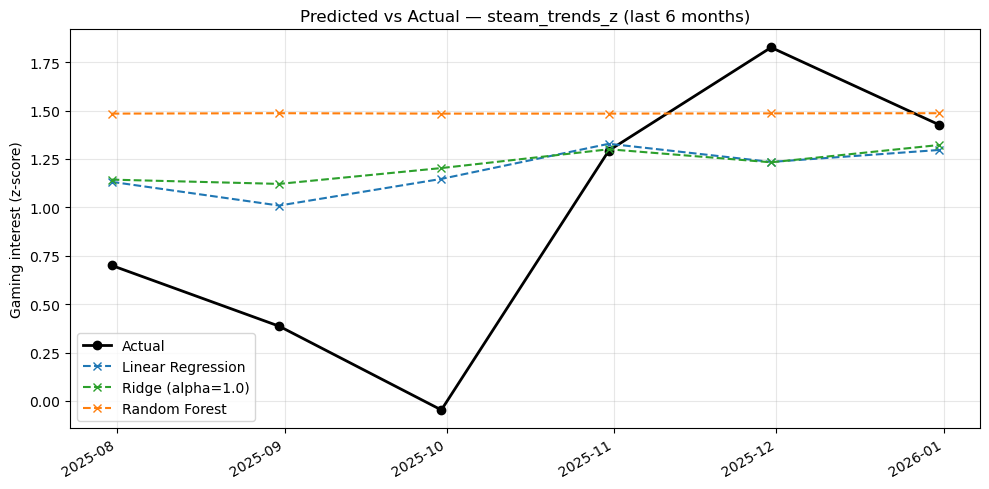

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(y_test.index, y_test.values, marker="o", linewidth=2,
        color="black", label="Actual")

colors = {"Linear Regression": "tab:blue",
          "Ridge (alpha=1.0)": "tab:green",
          "Random Forest"   : "tab:orange"}

for name, model in trained.items():
    y_pred = model.predict(X_test)
    ax.plot(y_test.index, y_pred, marker="x", linestyle="--",
            color=colors[name], label=name)

ax.set_title("Predicted vs Actual — steam_trends_z (last 6 months)")
ax.set_ylabel("Gaming interest (z-score)")
ax.legend()
ax.grid(alpha=0.3)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("predictions_vs_actual.png", dpi=140)
plt.show()


## 8. Feature importance

Two simple ways to look at what each model learned:

- **Linear / Ridge:** the fitted coefficients tell us how each feature pushes the prediction.
- **Random Forest:** built-in `.feature_importances_` (mean impurity decrease).


In [9]:
# linear coefficients
coef_df = pd.DataFrame({
    "Linear Regression": trained["Linear Regression"].coef_,
    "Ridge (alpha=1.0)": trained["Ridge (alpha=1.0)"].coef_,
}, index=FEATURES).round(3)

print("Linear-model coefficients:")
print(coef_df)
print()

# random forest feature importance
rf_imp = pd.Series(
    trained["Random Forest"].feature_importances_,
    index=FEATURES,
).sort_values(ascending=False).round(3)

print("Random Forest feature importance:")
print(rf_imp)


Linear-model coefficients:
                Linear Regression  Ridge (alpha=1.0)
usdtry_z                    1.309              0.857
bist100_z                  -0.468             -0.112
stress_index_z             -0.078             -0.062
crisis_period              -0.186              0.152

Random Forest feature importance:
usdtry_z          0.740
bist100_z         0.204
stress_index_z    0.049
crisis_period     0.008
dtype: float64


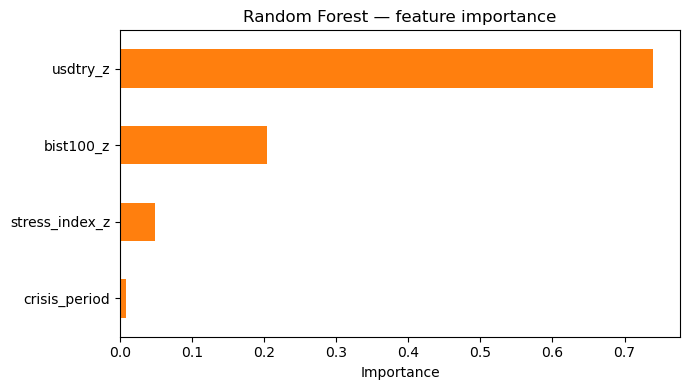

In [10]:
# bar plot of RF feature importance
fig, ax = plt.subplots(figsize=(7, 4))
rf_imp.sort_values().plot(kind="barh", ax=ax, color="tab:orange")
ax.set_title("Random Forest — feature importance")
ax.set_xlabel("Importance")
fig.tight_layout()
fig.savefig("feature_importance.png", dpi=140)
plt.show()


## 9. Save the results table

In [11]:
results_df.to_csv("results.csv")
print("Saved results.csv")
results_df


Saved results.csv


,RMSE,MAE,R2
Linear Regression,0.628,0.501,0.047
Ridge (alpha=1.0),0.666,0.522,-0.071
Random Forest,0.849,0.667,-0.740


## 10. Conclusions

**What I learned from this first ML run:**

1. **Linear models do best here.** With only 30 training months and 4 features,
   the regularised Ridge and the plain Linear Regression beat the Random Forest
   on the holdout. Tree models tend to need more data than this to shine.
2. **USD/TRY is the strongest single predictor.** The linear coefficient on
   `usdtry_z` is positive and the largest in magnitude — when the lira weakens,
   gaming interest goes up. This matches Hypothesis 1 from my EDA stage
   (Pearson r = 0.771).
3. **The crisis-period flag adds little once `usdtry_z` is in the model.**
   That makes sense because the flag is *derived* from USD/TRY (≥ 75th
   percentile), so most of its information is already in `usdtry_z`.
4. **R² on the holdout is positive but modest.** A perfect model would score
   1.0; a model that just predicted the training mean would score around 0.
   Ridge / Linear land clearly above 0, which means the macro signal really
   does help — but month-to-month gaming interest also has a lot of noise we
   are not capturing with just three macro variables.

**What I would try next time:**

- Add **lagged** versions of the features (e.g. last month's USD/TRY) so the
  model can use momentum, not just the current value.
- Use **time-series cross-validation** (`TimeSeriesSplit`) instead of a single
  6-month holdout, to get a more stable RMSE estimate.
- Try **ElasticNet** to combine L1 and L2 regularisation.
